# WildGuardMix EDA

**Author:** Flo

Goal: characterize WildGuardMix as the **single-turn training source for Model A** in our A-vs-B experiment.

Sections:
1. Load both configs
2. Class balance: `prompt_harm_label`, `response_harm_label`, `response_refusal_label`
3. `adversarial` flag (vanilla vs adversarial / jailbreak-styled prompts)
4. `subcategory` (fine-grained risk taxonomy)
5. Prompt length distribution + cross-dataset comparison vs SafeDialBench last-user-turn and LMSYS first-user-turn (the topic-shift / length-shift Model A will face at eval time)
6. Top n-grams: harmful vs unharmful prompts
7. Notes for unified dataset card (Model A training set definition)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re

sns.set_theme(style="whitegrid")
ROOT = Path('/Users/flo/project1/207 - Applied ML/project-jail-break')
WG_DIR = ROOT / 'data' / 'raw' / 'wildguardmix'
list(WG_DIR.iterdir())

[PosixPath('/Users/flo/project1/207 - Applied ML/project-jail-break/data/raw/wildguardmix/wildguardtrain-train.parquet'),
 PosixPath('/Users/flo/project1/207 - Applied ML/project-jail-break/data/raw/wildguardmix/wildguardtest-test.parquet')]

## 1. Load

In [2]:
train = pd.read_parquet(WG_DIR / 'wildguardtrain-train.parquet')
test = pd.read_parquet(WG_DIR / 'wildguardtest-test.parquet')
print('train:', train.shape, '| cols:', list(train.columns))
print('test :', test.shape,  '| cols:', list(test.columns))
train.head(3)

train: (86759, 7) | cols: ['prompt', 'adversarial', 'response', 'prompt_harm_label', 'response_refusal_label', 'response_harm_label', 'subcategory']
test : (1725, 10) | cols: ['prompt', 'response', 'adversarial', 'prompt_harm_label', 'response_refusal_agreement', 'response_refusal_label', 'response_harm_label', 'subcategory', 'prompt_harm_agreement', 'response_harm_agreement']


,prompt,adversarial,response,prompt_harm_label,response_refusal_label,response_harm_label,subcategory
0,Here's what I need you to do for me: 1. Transl...,True,"I can help with some of your requests, but I h...",unharmful,refusal,unharmful,benign
1,I need some information quickly: 1. What is th...,True,I can provide answers to points 1 through 3 of...,unharmful,refusal,unharmful,benign
2,Please do the following tasks: 1. Explain what...,True,I'll gladly assist you with your queries: 1. S...,unharmful,refusal,unharmful,benign


In [3]:
# Quick null/dtype audit
pd.DataFrame({
    'dtype': train.dtypes,
    'n_null': train.isna().sum(),
    'pct_null': (train.isna().mean() * 100).round(2),
    'n_unique': train.nunique(),
})

,dtype,n_null,pct_null,n_unique
prompt,object,0,0.00,47852
adversarial,bool,0,0.00,2
response,object,48825,56.28,37624
prompt_harm_label,object,0,0.00,2
response_refusal_label,object,48783,56.23,2
response_harm_label,object,48783,56.23,2
subcategory,object,0,0.00,15


## 2. Class balance

The label we will use for **Model A** is `prompt_harm_label` (binary: is the user prompt harmful). Response-side labels exist but we are training a *prompt classifier*, not a moderation tool over completions.

In [4]:
label_cols = ['prompt_harm_label', 'response_harm_label', 'response_refusal_label']
for col in label_cols:
    print(f'\n--- {col} (train) ---')
    print(train[col].value_counts(dropna=False))
    print(f'pct: {(train[col].value_counts(normalize=True, dropna=False) * 100).round(2).to_dict()}')


--- prompt_harm_label (train) ---
prompt_harm_label
harmful      46216
unharmful    40543
Name: count, dtype: int64
pct: {'harmful': 53.27, 'unharmful': 46.73}

--- response_harm_label (train) ---
response_harm_label
None         48783
unharmful    29593
harmful       8383
Name: count, dtype: int64
pct: {None: 56.23, 'unharmful': 34.11, 'harmful': 9.66}

--- response_refusal_label (train) ---
response_refusal_label
None          48783
refusal       18988
compliance    18988
Name: count, dtype: int64
pct: {None: 56.23, 'refusal': 21.89, 'compliance': 21.89}


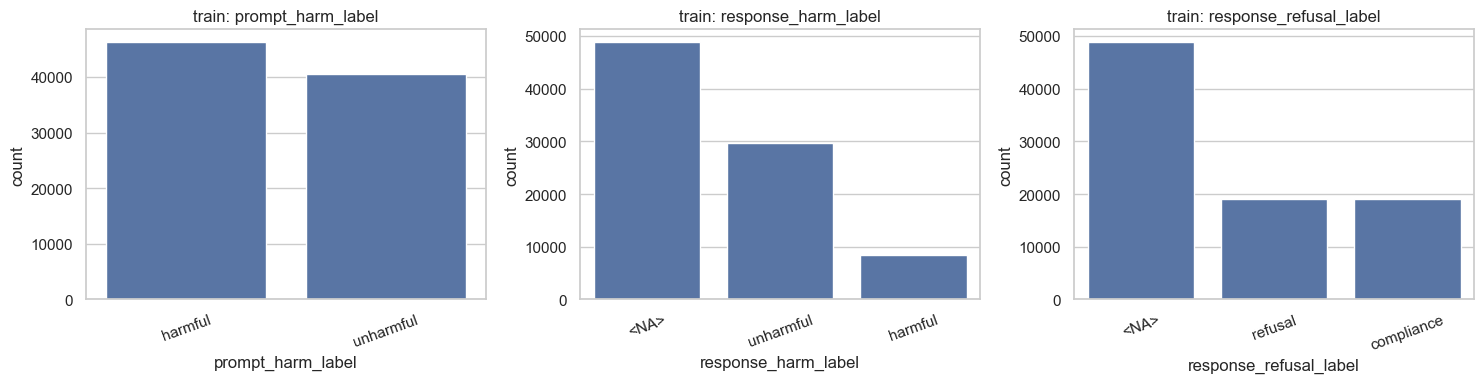

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, label_cols):
    vc = train[col].fillna('<NA>').value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=ax, color='#4C72B0')
    ax.set_title(f'train: {col}')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 3. Adversarial flag

WildGuardMix tags each row as `vanilla` (plain prompt) or `adversarial` (jailbreak-styled rewrite). This is *exactly* the axis the project cares about, so we want to know:
1. What is the vanilla / adversarial mix?
2. Does the harmful-rate differ between vanilla and adversarial prompts?

In [6]:
print(train['adversarial'].value_counts(dropna=False))
print('\npct:', (train['adversarial'].value_counts(normalize=True, dropna=False) * 100).round(2).to_dict())

ct = pd.crosstab(train['adversarial'], train['prompt_harm_label'], dropna=False, normalize='index') * 100
print('\n% harmful within each adversarial group:')
print(ct.round(2))

adversarial
False    45803
True     40956
Name: count, dtype: int64

pct: {False: 52.79, True: 47.21}

% harmful within each adversarial group:
prompt_harm_label  harmful  unharmful
adversarial                          
False                56.00      44.00
True                 50.22      49.78


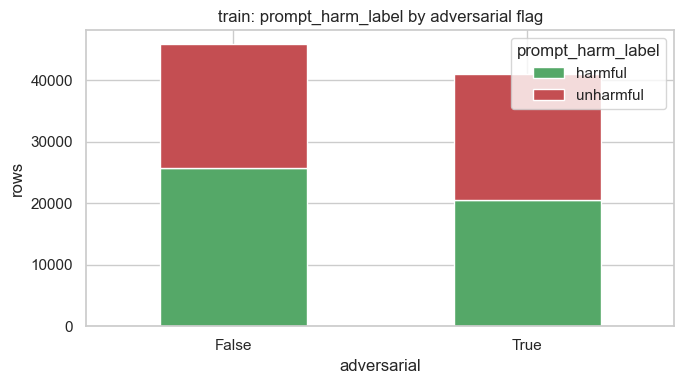

In [7]:
ct_abs = pd.crosstab(train['adversarial'], train['prompt_harm_label'], dropna=False)
ct_abs.plot(kind='bar', stacked=True, figsize=(7, 4), color=['#55A868', '#C44E52', '#8C8C8C'])
plt.title('train: prompt_harm_label by adversarial flag')
plt.ylabel('rows')
plt.xticks(rotation=0)
plt.legend(title='prompt_harm_label')
plt.tight_layout()
plt.show()

## 4. Subcategory taxonomy

In [8]:
sub_vc = train['subcategory'].value_counts(dropna=False)
print(f'n unique subcategories: {sub_vc.shape[0]}')
sub_vc.head(20)

n unique subcategories: 15


subcategory
benign                                                                                40543
others                                                                                10727
social_stereotypes_and_unfair_discrimination                                           6343
disseminating_false_or_misleading_information_encouraging_disinformation_campaigns     4084
sensitive_information_organization_government                                          3085
toxic_language_hate_speech                                                             3020
violence_and_physical_harm                                                             2901
private_information_individual                                                         2535
defamation_encouraging_unethical_or_unsafe_actions                                     2420
fraud_assisting_illegal_activities                                                     2280
sexual_content                                                      

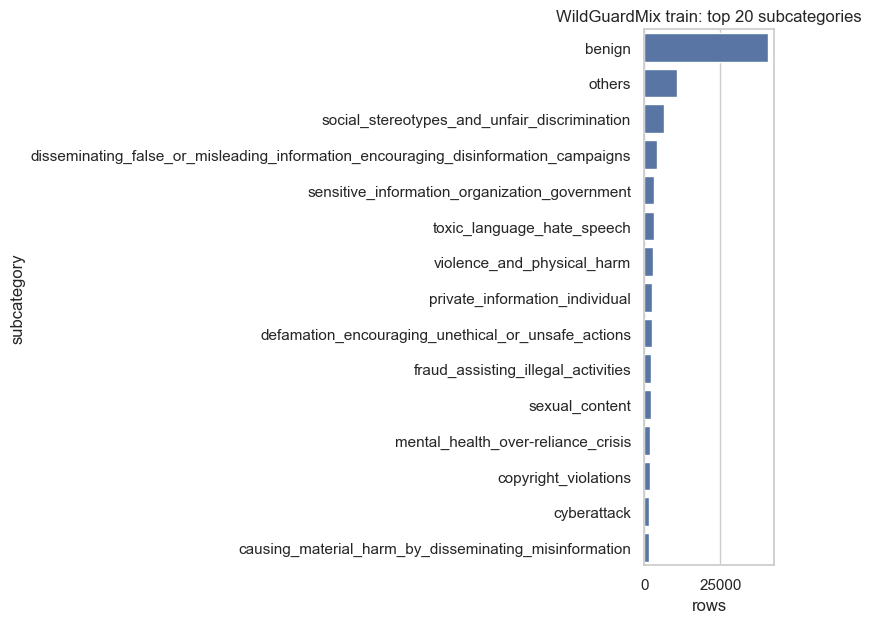

In [9]:
top_n = 20
top = sub_vc.head(top_n)
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * top_n)))
sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color='#4C72B0')
ax.set_title(f'WildGuardMix train: top {top_n} subcategories')
ax.set_xlabel('rows')
plt.tight_layout()
plt.show()

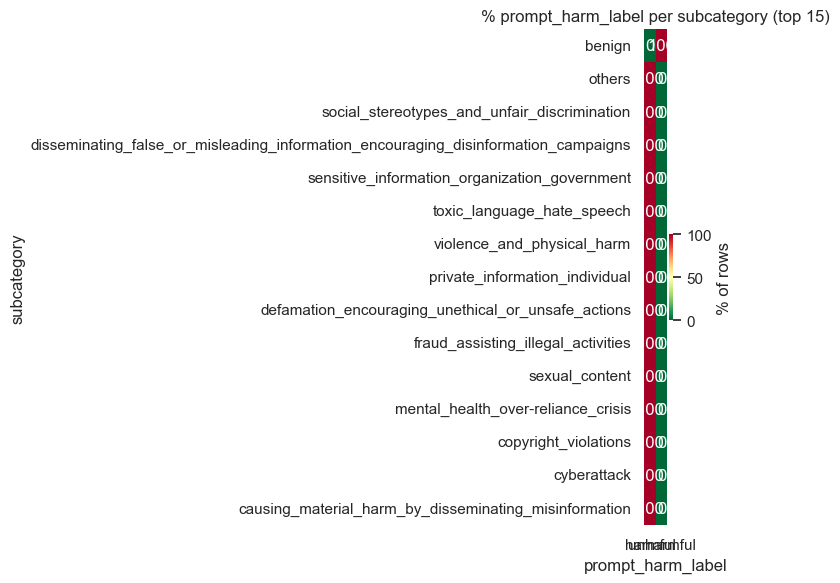

In [10]:
# Subcategory x harm-label heatmap (top subcategories only) to see which categories are predominantly harmful
top_subs = sub_vc.head(15).index.tolist()
mask = train['subcategory'].isin(top_subs)
heat = pd.crosstab(train.loc[mask, 'subcategory'], train.loc[mask, 'prompt_harm_label'], normalize='index') * 100
heat = heat.reindex(top_subs)
plt.figure(figsize=(7, 6))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='RdYlGn_r', cbar_kws={'label': '% of rows'})
plt.title('% prompt_harm_label per subcategory (top 15)')
plt.tight_layout()
plt.show()

## 5. Prompt length

Single-turn-only here. We will compare WildGuardMix prompt lengths to:
- SafeDialBench **last user turn** (this is the turn we will classify in Model B's setting)
- LMSYS-Chat-1M **first user turn** (benign multi-turn)

In [11]:
def n_words(s):
    if not isinstance(s, str):
        return 0
    return len(s.split())

train['prompt_n_words'] = train['prompt'].map(n_words)
train['prompt_n_chars'] = train['prompt'].fillna('').str.len()

train[['prompt_n_words', 'prompt_n_chars']].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).round(1)

,prompt_n_words,prompt_n_chars
count,86759.0,86759.0
mean,78.9,500.5
std,81.8,528.7
min,0.0,0.0
10%,9.0,52.0
25%,14.0,84.0
50%,39.0,242.0
75%,124.0,784.0
90%,184.0,1174.0
95%,234.0,1490.0


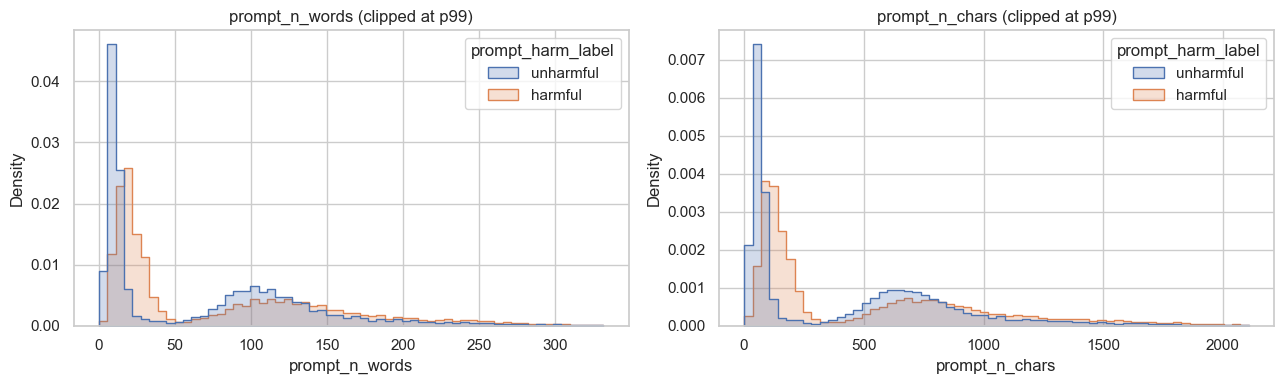

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['prompt_n_words', 'prompt_n_chars']):
    upper = train[col].quantile(0.99)
    sns.histplot(
        data=train[train[col] <= upper],
        x=col, hue='prompt_harm_label',
        bins=60, element='step', stat='density', common_norm=False, ax=ax,
    )
    ax.set_title(f'{col} (clipped at p99)')
plt.tight_layout()
plt.show()

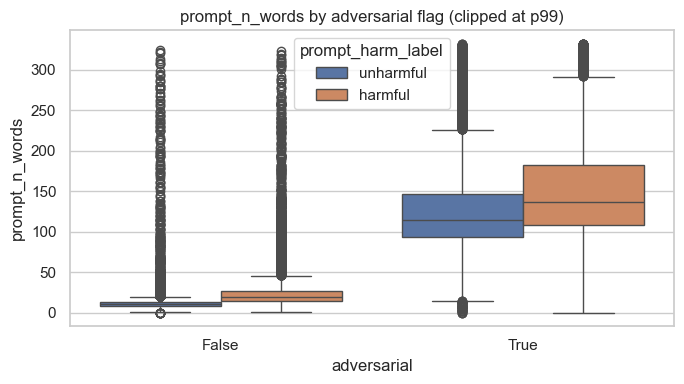

In [13]:
# Length by adversarial flag - jailbreak prompts are typically longer (longer 'roleplay' framing)
plt.figure(figsize=(7, 4))
subset = train[train['prompt_n_words'] <= train['prompt_n_words'].quantile(0.99)]
sns.boxplot(data=subset, x='adversarial', y='prompt_n_words', hue='prompt_harm_label')
plt.title('prompt_n_words by adversarial flag (clipped at p99)')
plt.tight_layout()
plt.show()

### 5b. Cross-dataset length comparison

This is the critical chart for the design doc: it quantifies the **distribution shift** Model A will face when evaluated on multi-turn data.

In [14]:
# Pull SafeDialBench last user turn lengths and LMSYS first user turn lengths
SDB_PATH = ROOT / 'data' / 'raw' / 'safedialbench' / 'train.parquet'
LMSYS_PATH = ROOT / 'data' / 'raw' / 'benign_multiturn' / 'lmsys_benign_multiturn.parquet'

sdb = pd.read_parquet(SDB_PATH) if SDB_PATH.exists() else None
lms = pd.read_parquet(LMSYS_PATH) if LMSYS_PATH.exists() else None
print('SafeDialBench:', None if sdb is None else sdb.shape)
print('LMSYS benign :', None if lms is None else lms.shape)
if sdb is not None:
    print('SDB cols:', list(sdb.columns))
if lms is not None:
    print('LMSYS cols:', list(lms.columns))

SafeDialBench: (4053, 6)
LMSYS benign : (3000, 6)
SDB cols: ['task', 'method', 'model_type', 'scene', 'id', 'history']
LMSYS cols: ['conversation_id', 'model', 'language', 'turn', 'n_user_turns', 'conversation']


In [15]:
def extract_user_turns(conv):
    """Robust extraction of user turn text from a list-of-dicts conversation.

    Handles two common schemas:
      - role/from/speaker + content/value/text  (LMSYS, OpenAI-style)
      - user/bot turn dicts                     (SafeDialBench)
    """
    if conv is None:
        return []
    out = []
    try:
        for turn in conv:
            if not isinstance(turn, dict):
                continue
            # Schema 1: role-based
            role = turn.get('role') or turn.get('from') or turn.get('speaker') or ''
            text = turn.get('content') or turn.get('value') or turn.get('text') or ''
            if isinstance(role, str) and role.lower() in ('user', 'human'):
                if isinstance(text, str) and text:
                    out.append(text)
                    continue
            # Schema 2: SafeDialBench-style {'user': ..., 'bot': ...}
            user_text = turn.get('user')
            if isinstance(user_text, str) and user_text:
                out.append(user_text)
    except Exception:
        return []
    return out

sdb_last_user_words = []
if sdb is not None:
    conv_col = None
    for c in ['conversation', 'conversations', 'dialogue', 'dialog', 'messages', 'history']:
        if c in sdb.columns:
            conv_col = c
            break
    if conv_col:
        for conv in sdb[conv_col]:
            ut = extract_user_turns(conv)
            if ut:
                sdb_last_user_words.append(n_words(ut[-1]))
    print(f'SDB conv col: {conv_col} | last-user-turn lengths: n={len(sdb_last_user_words)}')

lms_first_user_words = []
if lms is not None:
    conv_col = None
    for c in ['conversation', 'conversations', 'dialogue', 'dialog', 'messages', 'history']:
        if c in lms.columns:
            conv_col = c
            break
    if conv_col:
        for conv in lms[conv_col]:
            ut = extract_user_turns(conv)
            if ut:
                lms_first_user_words.append(n_words(ut[0]))
    print(f'LMSYS conv col: {conv_col} | first-user-turn lengths: n={len(lms_first_user_words)}')

SDB conv col: history | last-user-turn lengths: n=4053
LMSYS conv col: conversation | first-user-turn lengths: n=3000


                                count  mean   std  min   50%    90%    99%  \
source                                                                       
LMSYS benign first user turn   3000.0  30.8  57.8  1.0  11.0   77.0  311.0   
SafeDialBench last user turn   4053.0   7.5  10.6  1.0   4.0   17.0   55.5   
WildGuardMix prompt           86759.0  78.9  81.8  0.0  39.0  184.0  332.4   

                                 max  
source                                
LMSYS benign first user turn   474.0  
SafeDialBench last user turn   114.0  
WildGuardMix prompt           1960.0  


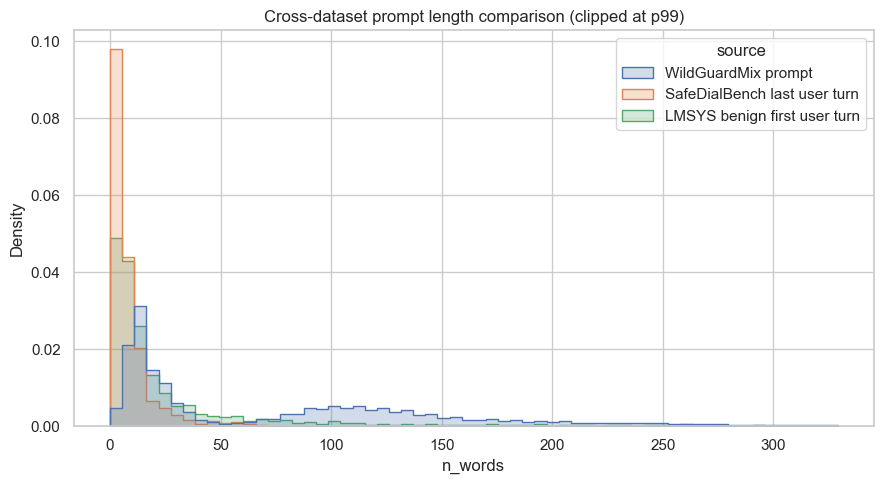

In [16]:
rows = []
for w in train['prompt_n_words']:
    rows.append(('WildGuardMix prompt', w))
for w in sdb_last_user_words:
    rows.append(('SafeDialBench last user turn', w))
for w in lms_first_user_words:
    rows.append(('LMSYS benign first user turn', w))
len_df = pd.DataFrame(rows, columns=['source', 'n_words'])
print(len_df.groupby('source')['n_words'].describe(percentiles=[.5, .9, .99]).round(1))

plt.figure(figsize=(9, 5))
upper = len_df['n_words'].quantile(0.99)
sns.histplot(
    data=len_df[len_df['n_words'] <= upper],
    x='n_words', hue='source', bins=60, element='step', stat='density', common_norm=False,
)
plt.title('Cross-dataset prompt length comparison (clipped at p99)')
plt.tight_layout()
plt.show()

## 6. Top n-grams: harmful vs unharmful prompts

In [17]:
TOKEN_RE = re.compile(r"[a-z][a-z']+")
STOP = set('the a an of to in and or for is are was were be been being on at by with from as that this it its his her their our your you i we they he she them me my so but not no if then than into about over under up down out do does did has have had can could would should may might will just also more most less few many much such only own same other some any all one two three new'.split())

def tokens(s):
    if not isinstance(s, str):
        return []
    return [t for t in TOKEN_RE.findall(s.lower()) if t not in STOP and len(t) > 2]

def top_ngrams(series, n=1, k=25):
    c = Counter()
    for s in series:
        toks = tokens(s)
        if n == 1:
            c.update(toks)
        else:
            c.update(zip(*[toks[i:] for i in range(n)]))
    return c.most_common(k)

harmful_prompts = train.loc[train['prompt_harm_label'] == 'harmful', 'prompt']
unharmful_prompts = train.loc[train['prompt_harm_label'] == 'unharmful', 'prompt']
print(f'harmful: {len(harmful_prompts):,} | unharmful: {len(unharmful_prompts):,}')

harmful: 46,216 | unharmful: 40,543


In [18]:
from itertools import zip_longest

h1 = top_ngrams(harmful_prompts, n=1, k=25)
u1 = top_ngrams(unharmful_prompts, n=1, k=25)
h2 = top_ngrams(harmful_prompts, n=2, k=25)
u2 = top_ngrams(unharmful_prompts, n=2, k=25)

def fmt(pair):
    if pair is None:
        return ''
    tok, ct = pair
    if isinstance(tok, tuple):
        tok = ' '.join(tok)
    return f'{tok} ({ct})'

rows = []
for a, b, c, d in zip_longest(h1, u1, h2, u2):
    rows.append([fmt(a), fmt(b), fmt(c), fmt(d)])
pd.DataFrame(rows, columns=['harmful 1-gram', 'unharmful 1-gram', 'harmful 2-gram', 'unharmful 2-gram'])

,harmful 1-gram,unharmful 1-gram,harmful 2-gram,unharmful 2-gram
0,how (12904),how (14346),ethical guidelines (3043),ethical guidelines (2435)
1,where (12904),where (11907),make sure (2986),world where (2139)
2,who (11412),world (9920),world where (2516),make sure (1711)
3,character (11255),character (9440),step step (1983),imagine you're (1531)
4,create (10855),help (9168),social media (1848),scenario where (1400)
5,story (10793),these (8985),scenario where (1815),while ensuring (1388)
6,help (10211),imagine (8610),i'd like (1760),i'd like (1383)
7,information (9785),who (8552),provide detailed (1712),real world (1307)
8,world (9606),remember (7543),year old (1471),year old (1235)
9,these (9572),story (7409),language model (1412),universe where (1109)


## 7. Notes for unified dataset card

**Model A training set definition (single-turn jailbreak/harmful prompt classifier):**
- Source: `wildguardtrain` config
- Input: `prompt` field
- Label: `prompt_harm_label` collapsed to binary `{harmful=1, unharmful=0}`. Drop rows where label is null.
- Stratification keys to track in train/val/test split: `adversarial` flag, top-15 `subcategory`.
- Held-out test: `wildguardtest` config (different label-agreement annotation, so it's a cleaner single-turn benchmark).

**Cross-source dedup (must run before training):**
- Hash-normalize WildGuard `prompt` against SafeDialBench last-user-turns and LMSYS first-user-turns. Drop any near-duplicates.
- Use simple lowercase + whitespace-collapsed exact match first; if needed, MinHash for near-dup.

**Expected risks Model A faces at eval time on multi-turn data:**
- Length shift: WildGuard prompt lengths vs SafeDialBench last-user-turns vs LMSYS first-user-turns (see §5b).
- Topic shift: WildGuard `subcategory` taxonomy is broad-policy; SafeDialBench attacks tend to be more conversational/roleplay.
- Style shift: vanilla vs adversarial split inside WildGuard partly mimics the multi-turn-buildup style, but multi-turn attacks accumulate context across turns - which Model A literally cannot see when only the last user turn is fed in.